# Separação de dados de treino e teste

In [89]:
# sample gathered from https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data/data

import pandas as pd
from sklearn.model_selection import train_test_split

# Load the training dataset
df = pd.read_csv('data.csv')


all_headers = df.columns.tolist()

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

print("Detected Columns:", all_headers)
cols_to_drop = ['id', 'Unnamed: 32']
df_clean = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

 # Malignant = 1, Benign = 0
y = df_clean['diagnosis'].map({'M': 1, 'B': 0})
X = df_clean.drop(columns=['diagnosis'])

# Will be used for mapping correlation and analysis only
df_clean['diagnosis'] = df_clean['diagnosis'].map({'M': 1, 'B': 0})

print("Cleaned Features (X) shape:", X.shape)
print("Cleaned Target (y) shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train shape: {X_train.shape}")  # (455 samples, 30 features)
print(f"X_test shape:  {X_test.shape}")   # (114 samples, 30 features)
print(f"y_train shape: {y_train.shape}")  # (455 labels)
print(f"y_test shape:  {y_test.shape}")   # (114 labels)



Detected Columns: ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']
Cleaned Features (X) shape: (569, 30)
Cleaned Target (y) shape: (569,)
X_train shape: (455, 30)
X_test shape:  (114, 30)
y_train shape: (455,)
y_test shape:  (114,)


# Analise


In [90]:
import matplotlib.pyplot as plt
import seaborn as sns


In [91]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print(f"Dataset Size: {df_clean.shape[0]}")
print(f"Columns: {df_clean.shape[1]}")
print("\n--- Dataset description ---")
print(df_clean.info())


Dataset Size: 569
Columns: 31

--- Dataset description ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se         

In [92]:
display(df_clean.describe().T)

,count,mean,std,min,25%,50%,75%,max
diagnosis,569.0,0.372583,0.483918,0.000000,0.000000,0.000000,1.000000,1.00000
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400


In [93]:
print("\n--- Diagnosys distribution ---")
class_counts = df_clean['diagnosis'].value_counts()
class_percentages = df_clean['diagnosis'].value_counts(normalize=True) * 100

print(f"Malignant (1): {class_counts[1]} ({class_percentages[1]:.2f}%)")
print(f"Benign (0): {class_counts[0]} ({class_percentages[0]:.2f}%)")


--- Diagnosys distribution ---
Malignant (1): 212 (37.26%)
Benign (0): 357 (62.74%)


<Axes: >

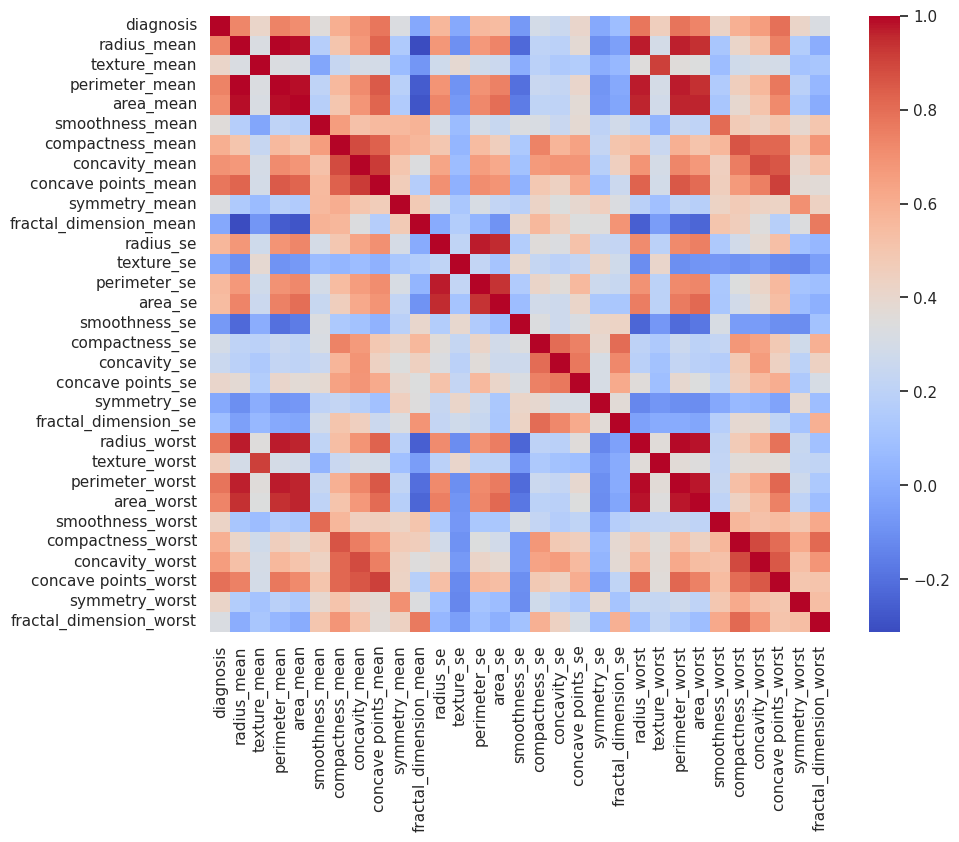

In [94]:

# Using df_clean with all data to make the analysis
correlacao = df_clean.corr()

plt.figure(figsize=(10, 8))
# Too much noise
sns.heatmap(correlacao,cmap="coolwarm")

## Criação de 0.5

<Axes: >

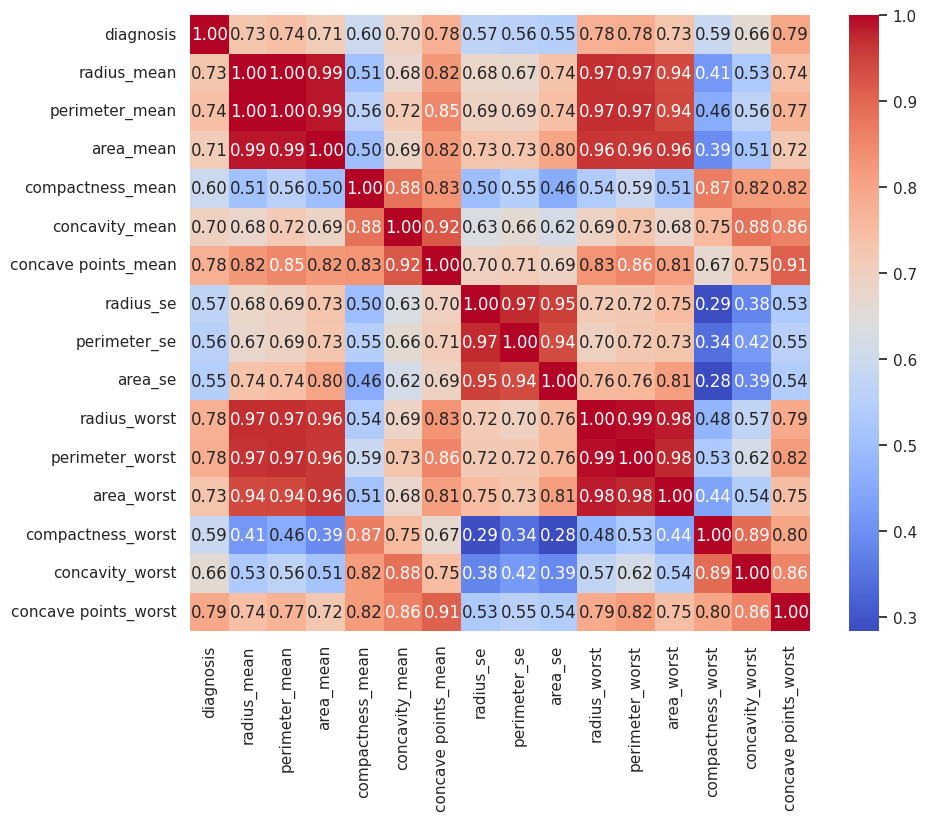

In [95]:
# Defines a filter point to eliminate less related column to our diagnosys
# this scenario we will use 0.5
target_corr = correlacao['diagnosis']
strong_cols = target_corr[target_corr.abs() >= 0.5].index

correlacao_filtrada = df_clean[strong_cols].corr()

strong_cols = strong_cols.drop('diagnosis')
X_train_05 = X_train[strong_cols].copy()
X_test_05 = X_test[strong_cols].copy()


plt.figure(figsize=(10, 8))
sns.heatmap(correlacao_filtrada, cmap="coolwarm", annot=True, fmt=".2f")


## Criação de 0.6

<Axes: >

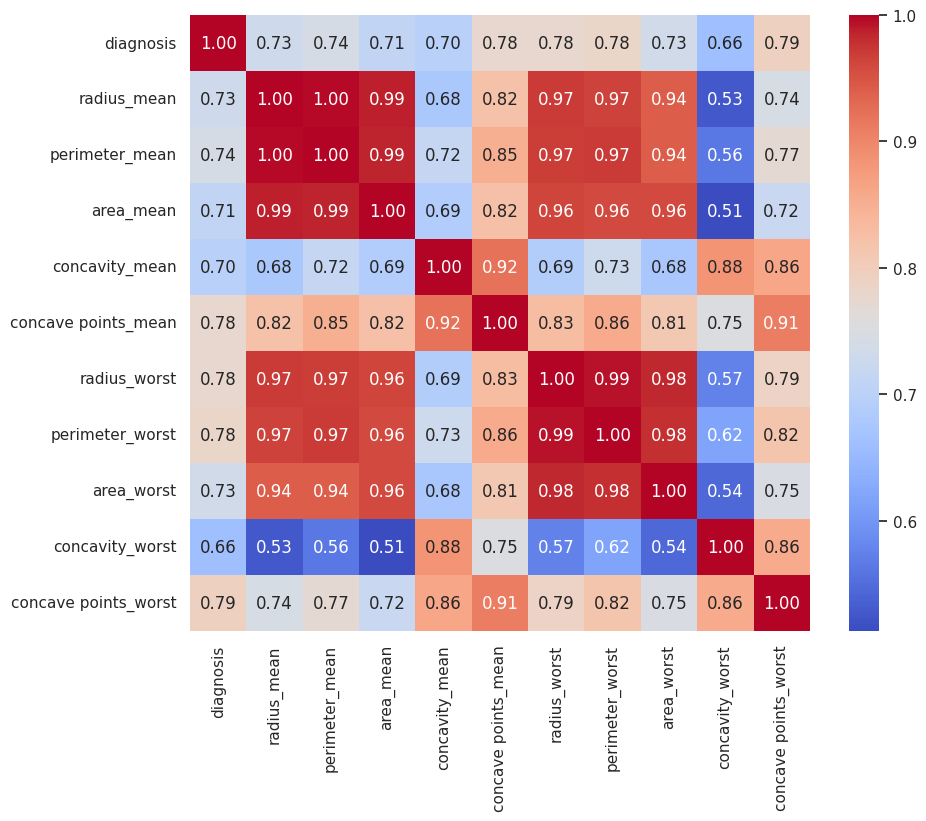

In [96]:
# Defines a filter point to eliminate less related column to our diagnosys
# this scenario we will use 0.6
target_corr = correlacao['diagnosis']
strong_cols = target_corr[target_corr.abs() >= 0.6].index

correlacao_filtrada = df_clean[strong_cols].corr()

strong_cols = strong_cols.drop('diagnosis')
X_train_06 = X_train[strong_cols].copy()
X_test_06 = X_test[strong_cols].copy()

plt.figure(figsize=(10, 8))
sns.heatmap(correlacao_filtrada, cmap="coolwarm", annot=True, fmt=".2f")

In [97]:
# Verify each each column before proceding to the trainig
print("DF (> 0.5) shape:", X_train_05.shape)
print("DF (> 0.6) shape:", X_train_06.shape)

DF (> 0.5) shape: (455, 15)
DF (> 0.6) shape: (455, 10)


# Treinamento e avaliação do modelo

In [98]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
import numpy as np
import shap
trained_models = {}
scoring_metrics = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

In [99]:
correlation_filter = "above 0.5"
models = {
    "Regressão logistica": LogisticRegression(random_state=42),
    "Arvore": DecisionTreeClassifier(max_depth=4,random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=4)
}
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_05)
X_test_scaled = scaler.transform(X_test_05)
cv_results_list = []

for name, model in models.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', model)
    ])
    model.fit(X_train_scaled, y_train)

    key_name = f"{name}_{correlation_filter}"
    trained_models[key_name] = model

    scores = cross_validate(
        pipeline,
        X_train_05,
        y_train,
        cv=cv_strategy,
        scoring=scoring_metrics
    )
    preds = model.predict(X_test_scaled)

    cv_results_list.append({
        "Model": name,
        "Accuracy": f"{scores['test_accuracy'].mean():.4f} (±{scores['test_accuracy'].std():.4f})",
        "Recall ": f"{scores['test_recall'].mean():.4f} (±{scores['test_recall'].std():.4f})",
        "F1-Score": f"{scores['test_f1'].mean():.4f} (±{scores['test_f1'].std():.4f})"
    })

df_cv_results = pd.DataFrame(cv_results_list)
print("--- Cross validation  ---")
display(df_cv_results)

--- Cross validation  ---


,Model,Accuracy,Recall,F1-Score
0,Regressão logistica,0.9429 (±0.0322),0.9000 (±0.0546),0.9213 (±0.0447)
1,Arvore,0.9253 (±0.0201),0.8647 (±0.0546),0.8957 (±0.0305)
2,KNN,0.9385 (±0.0365),0.8706 (±0.0576),0.9133 (±0.0511)


In [100]:
correlation_filter = "above 0.6"
models = {
    "Regressão logistica": LogisticRegression(random_state=42),
    "Arvore": DecisionTreeClassifier(max_depth=4,random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=4)
}
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_06)
X_test_scaled = scaler.transform(X_test_06)
cv_results_list = []

for name, model in models.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', model)
    ])
    model.fit(X_train_scaled, y_train)

    key_name = f"{name}_{correlation_filter}"
    trained_models[key_name] = model

    scores = cross_validate(
        pipeline,
        X_train_06,
        y_train,
        cv=cv_strategy,
        scoring=scoring_metrics
    )
    preds = model.predict(X_test_scaled)

    cv_results_list.append({
        "Model": name,
        "Accuracy": f"{scores['test_accuracy'].mean():.4f} (±{scores['test_accuracy'].std():.4f})",
        "Recall ": f"{scores['test_recall'].mean():.4f} (±{scores['test_recall'].std():.4f})",
        "F1-Score": f"{scores['test_f1'].mean():.4f} (±{scores['test_f1'].std():.4f})"
    })

df_cv_results = pd.DataFrame(cv_results_list)
print("--- Cross validation  ---")
display(df_cv_results)

--- Cross validation  ---


,Model,Accuracy,Recall,F1-Score
0,Regressão logistica,0.9538 (±0.0322),0.9176 (±0.0471),0.9370 (±0.0436)
1,Arvore,0.9253 (±0.0273),0.8765 (±0.0471),0.8973 (±0.0378)
2,KNN,0.9429 (±0.0290),0.8765 (±0.0506),0.9194 (±0.0407)


## Corte de 0.5

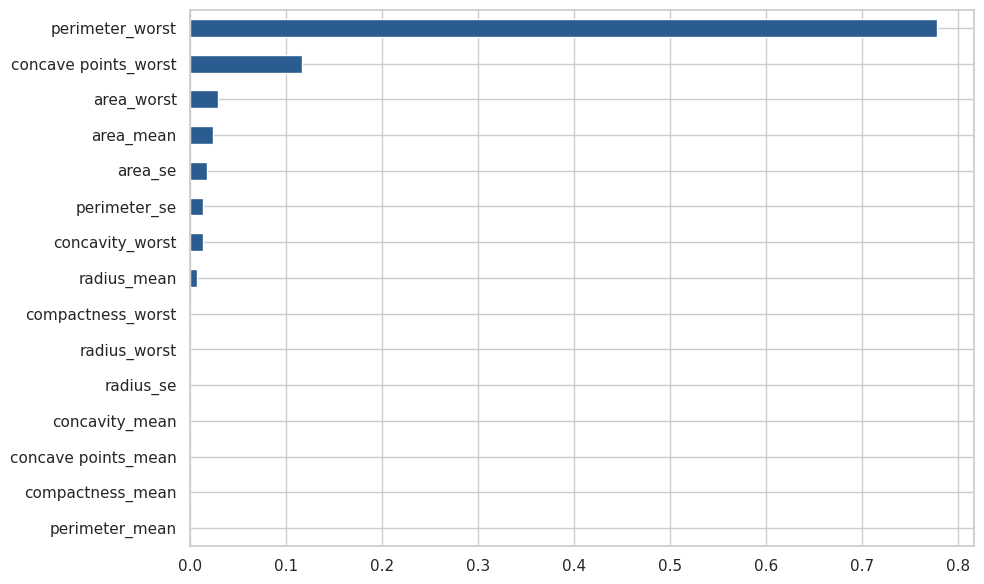

In [101]:
tree_05 = trained_models.get('Arvore_above 0.5')

importances = pd.Series(tree_05.feature_importances_, index=X_train_05.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='#2b5c8f')
plt.tight_layout()
plt.show()



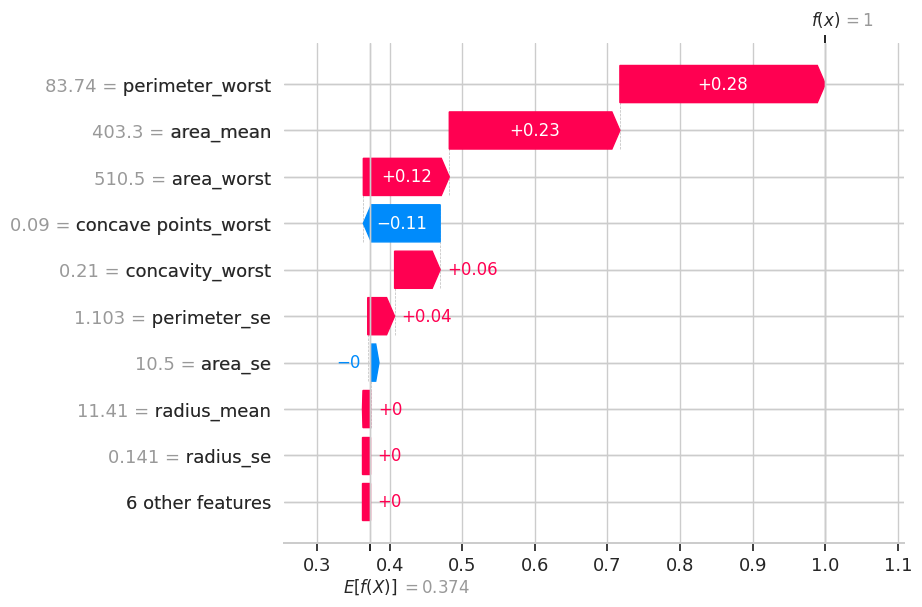

In [102]:
plt.close('all')

explainer = shap.TreeExplainer(tree_05)
shap_values = explainer.shap_values(X_test_05)

if isinstance(shap_values, list):
    shap_vals_target = shap_values[1]
else:
    shap_vals_target = shap_values

sample_idx = 0
plt.figure(figsize=(10, 6))
shap.plots.waterfall(
    shap.Explanation(
        values=shap_vals_target[sample_idx][:, 1],
        base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value,
        data=X_test_05.iloc[sample_idx],
        feature_names=X_test_05.columns
    )
)

## Corte de 0.6

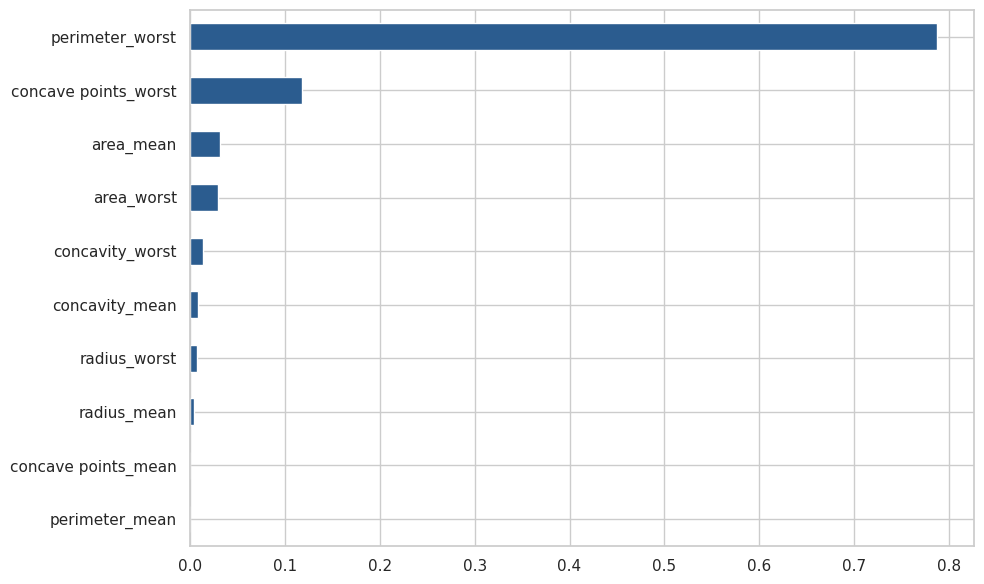

In [103]:
tree_06 = trained_models.get('Arvore_above 0.6')

importances = pd.Series(tree_06.feature_importances_, index=X_train_06.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='#2b5c8f')
plt.tight_layout()
plt.show()

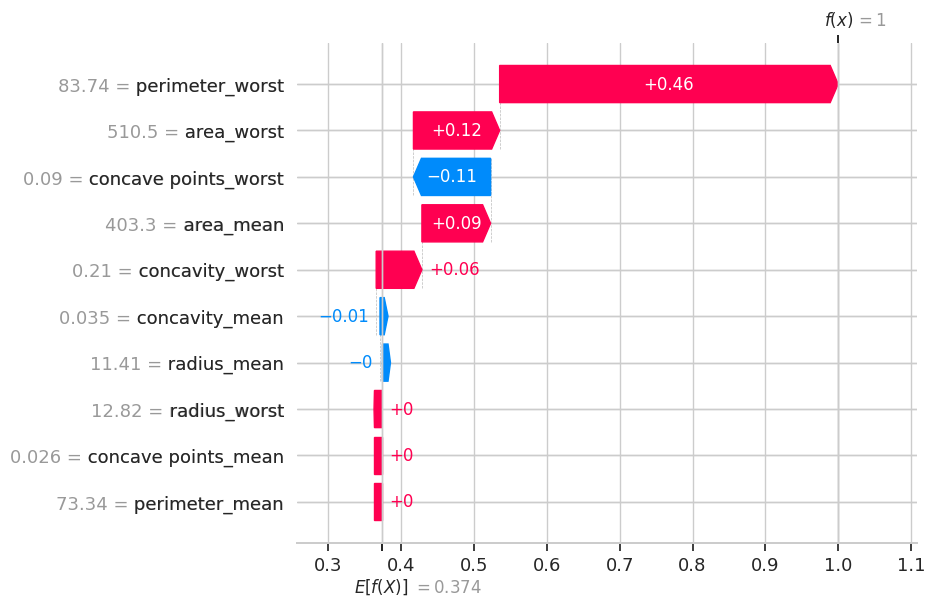

In [104]:
plt.close('all')

explainer = shap.TreeExplainer(tree_06)
shap_values = explainer.shap_values(X_test_06)

if isinstance(shap_values, list):
    shap_vals_target = shap_values[1]
else:
    shap_vals_target = shap_values

sample_idx = 0
plt.figure(figsize=(10, 6))
shap.plots.waterfall(
    shap.Explanation(
        values=shap_vals_target[sample_idx][:, 1],
        base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value,
        data=X_test_06.iloc[sample_idx],
        feature_names=X_test_06.columns
    )
)